# Assignment 1 - [Gandla Akshay Kumar]_[REDACTED]

# Task 0: Data Visualization (0%, but encourage for understanding data)

In [4]:
# write your code here, make sure you include 1 to 2 lines explanation on code
import pandas as pd
import numpy as np
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
import random


seed_value = 42

torch.manual_seed(seed_value)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed_value)
np.random.seed(seed_value)
random.seed(seed_value)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

TRAIN_CSV = "/content/Train_label.csv"
TEST_CSV  = "/content/Test_label.csv"
TRAIN_DIR = "/content/train_images"
TEST_DIR  = "/content/test_images"



Explanation: Here i imported all the necessary libraries that are required for training the model and then i set the seed value where it helps us to divide the same sequence in each step and then i gave the filepaths to the labels.

# Task 1: Data Preprocessing

### 1.1 Data Cleaning (2%)

In [8]:
# write your code here, make sure you include 1 to 2 lines explanation on code
train=pd.read_csv(TRAIN_CSV,header=None,names=["filename","label"])
test=pd.read_csv(TEST_CSV,header=None,names=["filename","label"])

train["label"]=train["label"].astype(str).str.strip()
test["label"]=test["label"].astype(str).str.strip()
train_unknown = train["label"].eq("?")
test_unknown  = test["label"].eq("?")

train_clean   = train.loc[~train_unknown].reset_index(drop=True)
test_labeled  = test.loc[~test_unknown].reset_index(drop=True)
test_unlabeled= test.loc[test_unknown].reset_index(drop=True)

print(f"Removed from train: {train_unknown.sum()} | kept: {len(train_clean)}")
print(f"Test unlabeled rows: {test_unknown.sum()} | labeled kept: {len(test_labeled)}")


classes  = sorted(train_clean["label"].unique())
label2id = {c:i for i,c in enumerate(classes)}
train_clean["label_idx"]  = train_clean["label"].map(label2id).astype(int)
test_labeled["label_idx"] = test_labeled["label"].map(label2id).astype(int)


train_clean.to_csv("/content/Train_label_clean.csv", index=False, header=False)
test_labeled.to_csv("/content/Test_label_labeled.csv", index=False, header=False)
test_unlabeled.to_csv("/content/Test_label_unlabeled.csv", index=False, header=False)

print("Saved:")
print(" - /content/Train_label_clean.csv")
print(" - /content/Test_label_labeled.csv")
print(" - /content/Test_label_unlabeled.csv")

Removed from train: 3 | kept: 117
Test unlabeled rows: 0 | labeled kept: 30
Saved:
 - /content/Train_label_clean.csv
 - /content/Test_label_labeled.csv
 - /content/Test_label_unlabeled.csv


Explnation: Loads the raw train/test label CSVs, trims whitespace, splits out rows with “?” labels, encodes class labels to integers, and saves cleaned/labeled/unlabeled CSVs.

### 1.2 Data Processing (2%)

In [9]:
# write your code here, make sure you include 1 to 2 lines explanation on code


# ---- Paths ----
TRAIN_DIR = "/content/train_images"
TEST_DIR  = "/content/test_images"
TRAIN_CSV_CLEAN = "/content/Train_label_clean.csv"
TEST_CSV_LABELED = "/content/Test_label_labeled.csv"

train_df = pd.read_csv(TRAIN_CSV_CLEAN, header=None, names=["filename","label","label_idx"])
test_df  = pd.read_csv(TEST_CSV_LABELED, header=None, names=["filename","label","label_idx"])

train_df["label_idx"] = train_df["label_idx"].astype(int)
test_df["label_idx"]  = test_df["label_idx"].astype(int)

print("Loaded (after cleaning):", len(train_df), "train rows,", len(test_df), "test rows.")


IMG_SIZE = 64
base_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),  # scales to [0,1]
])

print("Base preprocessing ready: Resize -> ToTensor (no augmentation).")



Loaded (after cleaning): 117 train rows, 30 test rows.
Base preprocessing ready: Resize -> ToTensor (no augmentation).


Explanation:Points to the cleaned CSVs, loads them into DataFrames, ensures label_idx is int, sets a base preprocessing pipeline (Resize→ToTensor), and prints dataset sizes.

### 1.3 Data Split and Loader (2%)

In [13]:
# write your code here, make sure you include 1 to 2 lines explanation on code
from PIL import Image
import os

class CSVDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = os.path.join(self.img_dir, self.dataframe.iloc[idx, 0])
        image = Image.open(img_name).convert("RGB")
        label = self.dataframe.iloc[idx, 2]
        if self.transform:
            image = self.transform(image)

        return image, label


IMG_SIZE = 64
base_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(), # scales to [0,1]
])


train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(), # scales to [0,1]

])


# Spliting the training data into training and validation sets
train_df_split, val_df_split = train_test_split(train_df, test_size=0.2, random_state=42)

print(len(train_df_split), "train rows,", len(val_df_split), "val rows.")

# 3) DataLoaders
BATCH_SIZE = 32

train_ds = CSVDataset(train_df_split, TRAIN_DIR, transform=train_transforms)
val_ds   = CSVDataset(val_df_split,   TRAIN_DIR, transform=base_transforms)
test_ds  = CSVDataset(test_df,        TEST_DIR,  transform=base_transforms)


train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


xb, yb = next(iter(train_loader))
print(xb.shape, yb[:5])

93 train rows, 24 val rows.
torch.Size([32, 3, 64, 64]) tensor([0, 3, 2, 2, 2])


Explanation:Implements a custom CSVDataset to read images + labels, splits training into train/val, builds DataLoaders for train/val/test, and sanity-checks by fetching one batch.

### 1.4 Data Augmentation

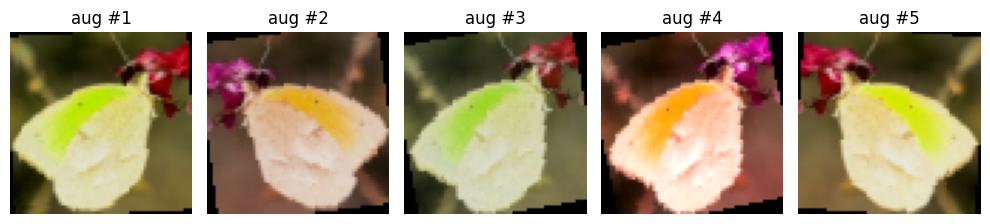

In [15]:
from typing_extensions import dataclass_transform
# write your code here, make sure you include 1 to 2 lines explanation on code
IMG_SIZE=64
train_transforms=transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    ])
eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

sample_path = "/content/train_images/Image_1000.jpg"
img = Image.open(sample_path).convert("RGB")


fig, axes = plt.subplots(1, 5, figsize=(10, 2.2))
for i in range(5):
    aug = train_transforms(img)
    axes[i].imshow(aug.permute(1, 2, 0))
    axes[i].set_title(f"aug #{i+1}")
    axes[i].axis("off")
plt.tight_layout(); plt.show()


Explnation:Defines train-time augmentation (flip, rotation, color jitter) and eval transforms, then visualizes several augmented views of a sample to verify preprocessing.

# Task 2: Training Loop (7%)

### 2.1 Model Architecture (2%)

In [20]:
# write your code here, make sure you include 1 to 2 lines explanation on code
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


try:
    num_classes = len(classes)
except:
    num_classes = int(train_df["label_idx"].nunique())
class TinyCNN(nn.Module):
  def __init__(self, n_classes):
        super().__init__()
        self.f = nn.Sequential(
            nn.Conv2d(3,16,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 64→32
            nn.Conv2d(16,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2)  # 32→16
        )
        self.c = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32*16*16, 64), nn.ReLU(),
            nn.Linear(64, n_classes)
        )
  def forward(self,x): return self.c(self.f(x))



Explnation:Selects device (GPU/CPU), infers num_classes, and declares a tiny CNN (two conv-pool blocks + MLP head) for image classification.

### 2.2 Training Loop (5%)

In [21]:
# write your code here, make sure you include 1 to 2 lines explanation on code
model = TinyCNN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
def run_epoch(loader, train=True):
    model.train(train)
    total, correct, loss_sum = 0, 0, 0.0
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        if train: optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        if train:
            loss.backward()
            optimizer.step()
        loss_sum += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
        total += x.size(0)
    return loss_sum / max(1,total), correct / max(1,total)

EPOCHS = 1
for ep in range(1, EPOCHS+1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(val_loader,   train=False)
    print(f"Epoch {ep:02d} | train loss {tr_loss:.4f} acc {tr_acc:.3f} | val loss {va_loss:.4f} acc {va_acc:.3f}")


te_loss, te_acc = run_epoch(test_loader, train=False)
print(f"[TEST] loss {te_loss:.4f} | acc {te_acc:.3f}")


Epoch 01 | train loss 1.4554 acc 0.409 | val loss 1.2409 acc 0.458
[TEST] loss 1.1740 | acc 0.533


Explnation:Instantiates the model, loss (CrossEntropyLoss), and optimizer (Adam), implements a train/validate loop that reports loss/accuracy, and evaluates on the test loader at the end.